In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<Axes: >

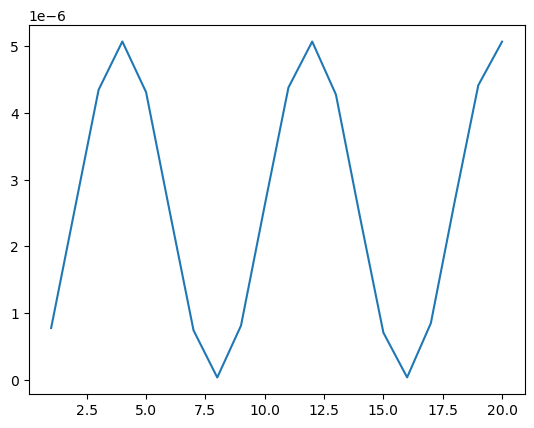

In [14]:
df = pd.read_csv("output.csv")
df["beam waist"][1:].plot()
# df["beam waist"].plot()

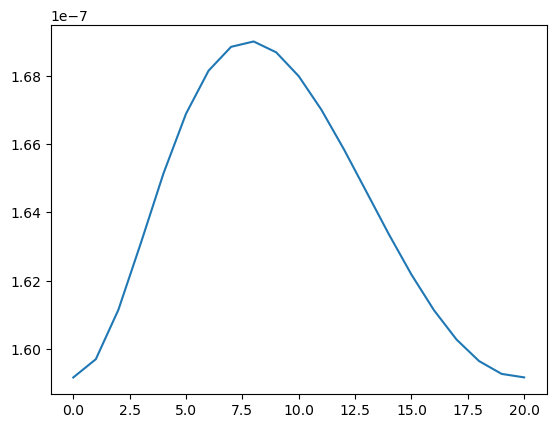

In [11]:
q_real = df["q param real"]
q_imag = df["q param imag"]
waist = (500e-9 / np.pi) * ((q_imag + (q_real)**2)/q_imag)
plt.plot(waist)
plt.show()

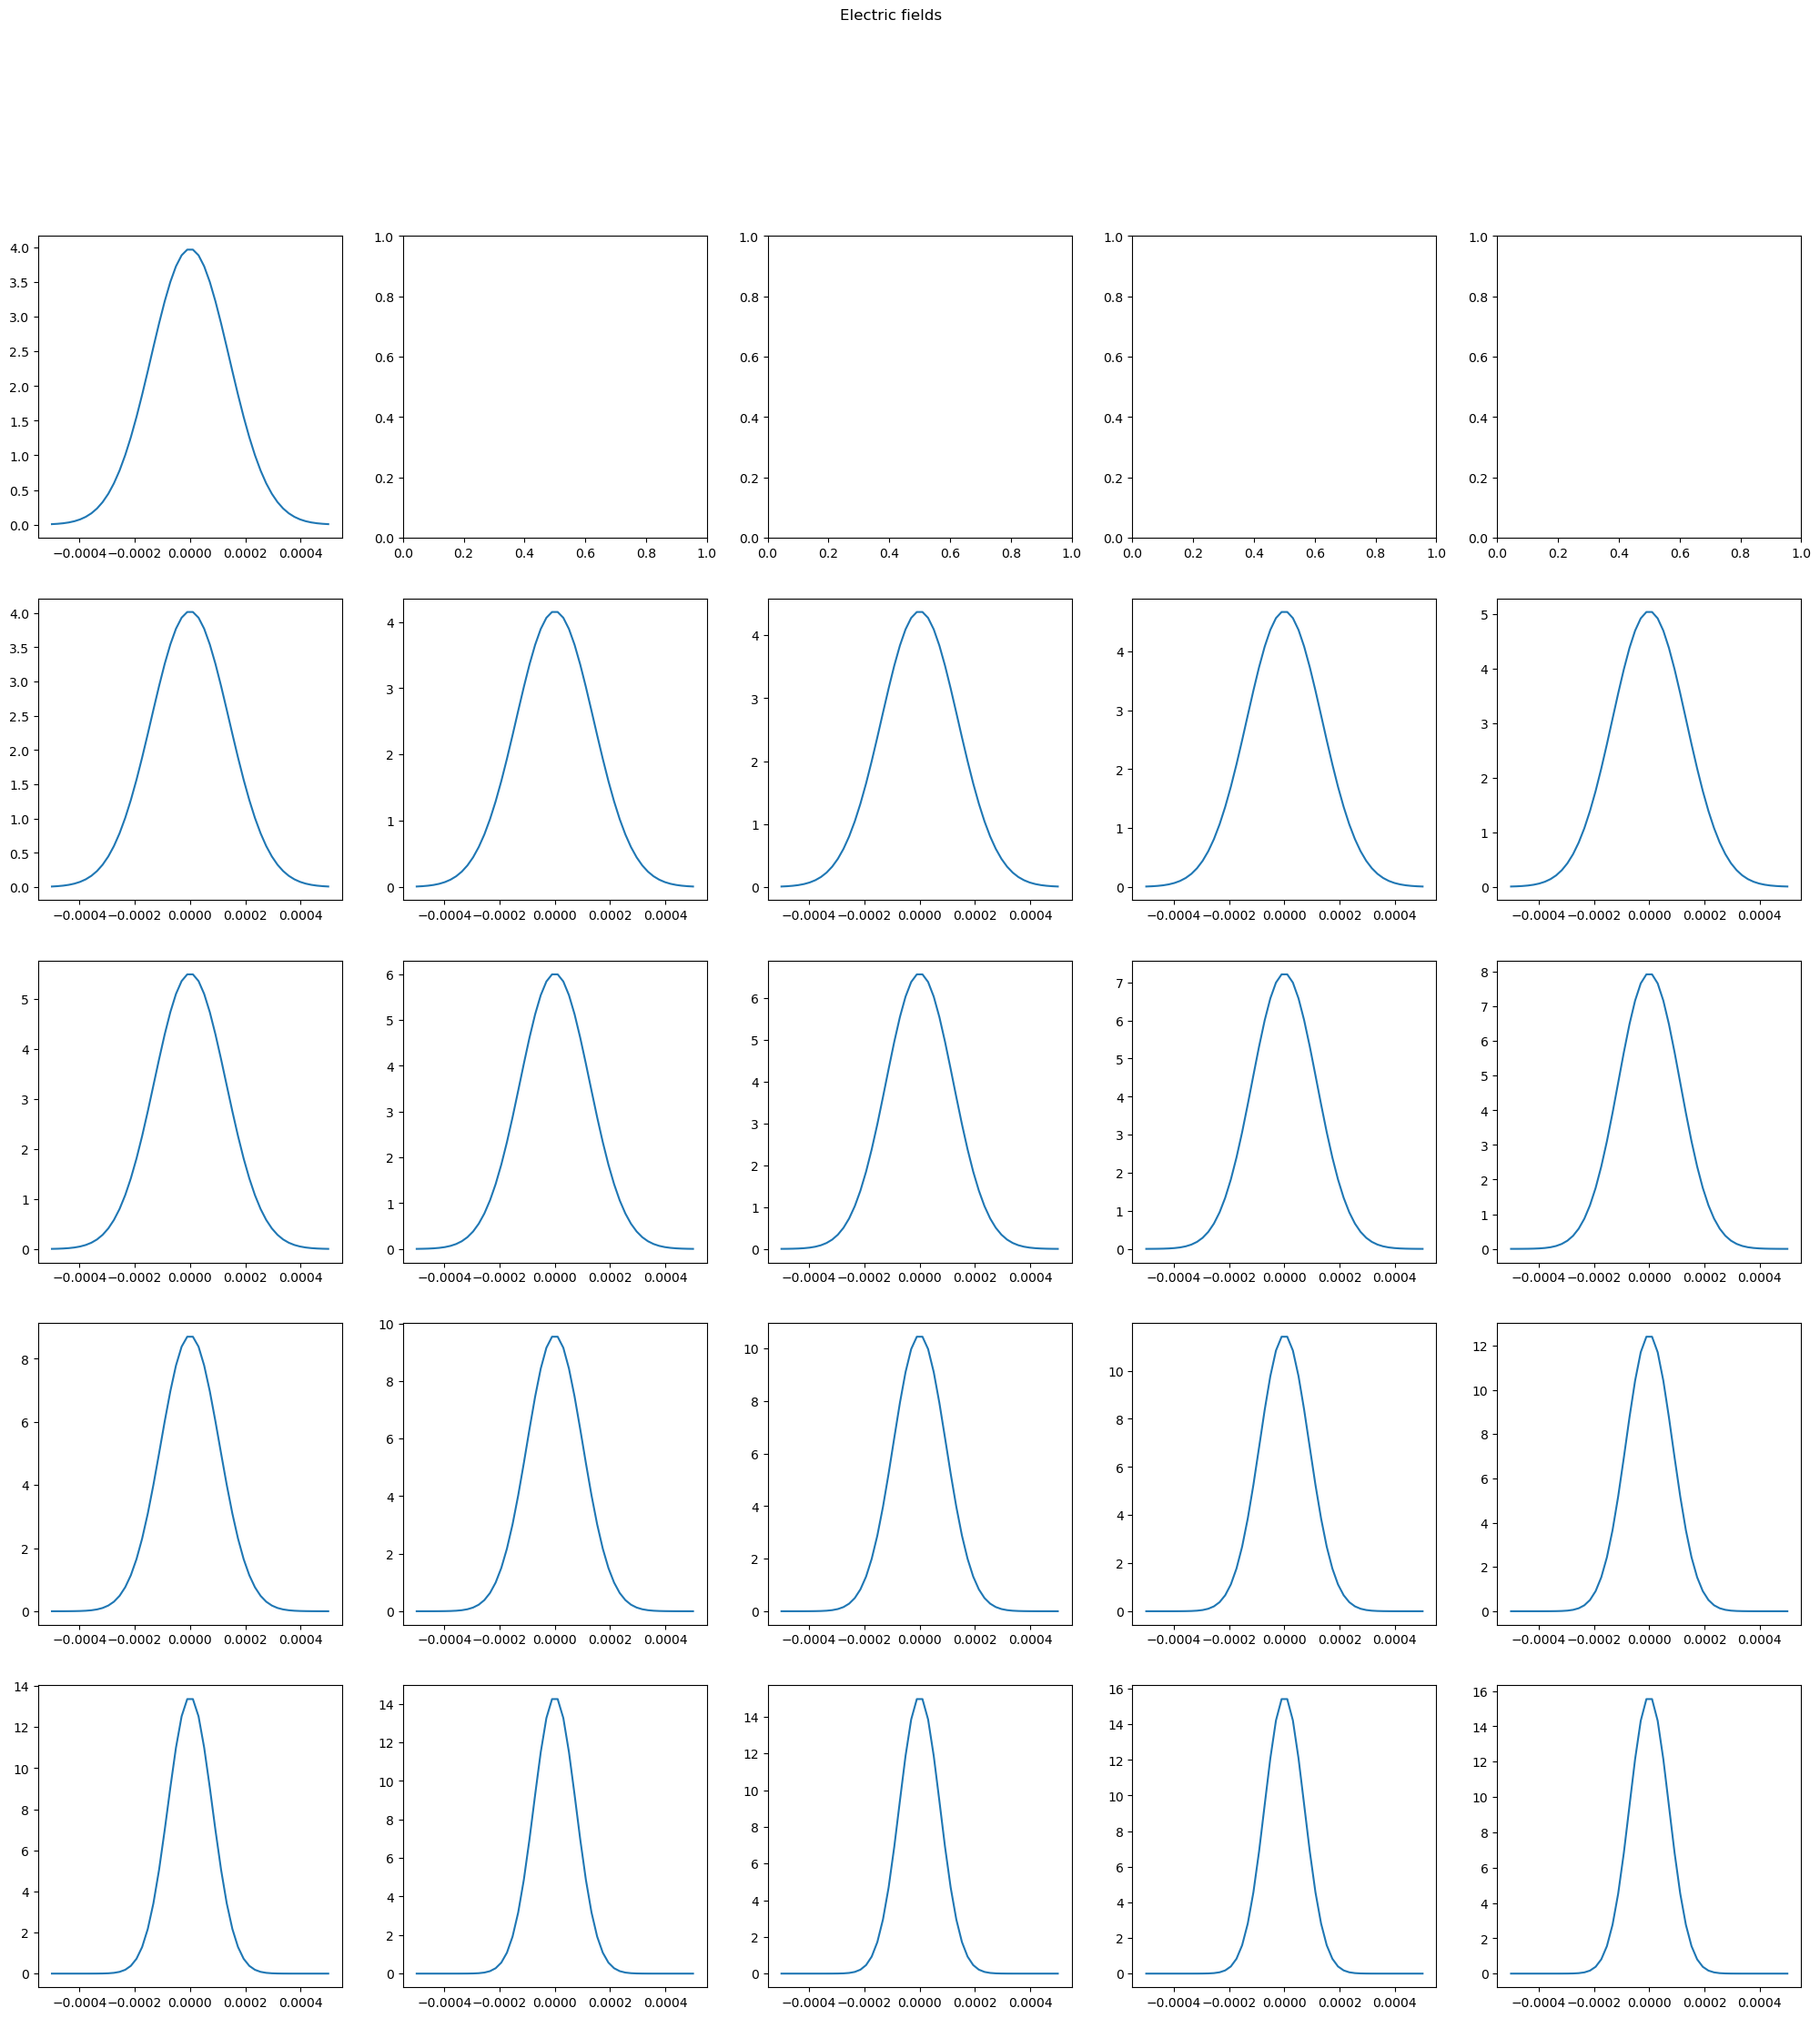

In [12]:
# Plotting electric field

"""A_0*q_0 = 1"""

width = 1000e-6
wavelength = 500e-09
x = np.linspace(-width/2, width/2, 50)
k = 2*np.pi/wavelength

fig, axes = plt.subplots(5, 5)
fig.set_figheight(25)
fig.set_figwidth(25)
plt.suptitle("Electric fields")

q_real = df.iloc[0]["q param real"]
q_imag = df.iloc[0]["q param imag"]
q = q_real + 1j*q_imag
E = (1/(q)) * np.exp(-1j * k * (q_real + (x**2 / (2 * (q)))))
axes[0, 0].plot(x, np.abs(E))
for i in range(1,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    E = (1/(q)) * np.exp(-1j * k * (q_real + (x**2 / (2 * (q)))))
    axes[(i+4)//5, (i-1)%5].plot(x, np.abs(E))

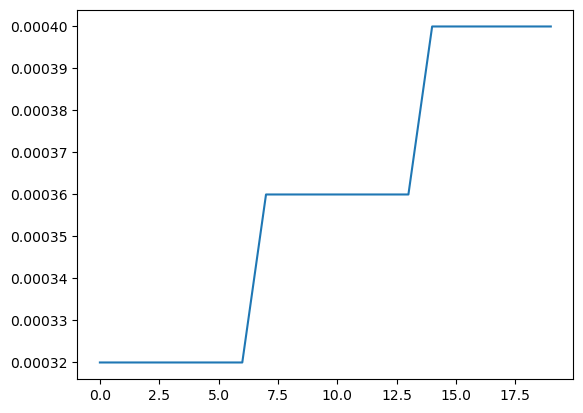

In [6]:
fwhm = []
X = np.linspace(-width/2, width/2, 50)
for i in range(1,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + (x**2 / (2 * (q))))))

    half_max = max(Y) / 2.
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.argmax(Y > half_max)
    fwhm.append((25 - left_idx)*2 * width/50) #return the difference (full width)

plt.plot(fwhm)
plt.show()
